# ## 0. Setup & Imports
# Standard libraries for data science, plotting and modeling.

In [1]:
# Basic imports
import os
import math
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NOTE: when making plots we will use matplotlib (no custom color palettes)
# Other useful libs
import seaborn as sns                # imported for convenience but main plotting uses matplotlib
from scipy import stats

# scikit-learn for preprocessing & models
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance

# for saving the model
import pickle

print("Libraries imported.")

Libraries imported.


## ## 1. Load dataset & Data Understanding
### - Load CSV
### - Show shape, columns, dtypes
### - Missing value counts & percentages
### - Unique values per column
### - Sample rows
### - Try automatic datatype conversions (datetime, boolean-like)

In [3]:
DATA_PATH = r"../data/road_accidents/train.csv"   # adjust path if needed

# Load
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

# Basic head & dtypes
display(df.head())
print("\nColumn dtypes:")
print(df.dtypes)

# Missing values
missing = pd.DataFrame({
    'num_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().mean()*100).round(2),
    'n_unique': [df[c].nunique(dropna=False) for c in df.columns],
    'dtype': df.dtypes.astype(str)
}).sort_values('pct_missing', ascending=False)
display(missing)

# duplicates
print("Duplicate rows:", df.duplicated().sum())


Loaded: ../data/road_accidents/train.csv
Shape: (517754, 14)


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56



Column dtypes:
id                          int64
road_type                  object
num_lanes                   int64
curvature                 float64
speed_limit                 int64
lighting                   object
weather                    object
road_signs_present           bool
public_road                  bool
time_of_day                object
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
dtype: object


,num_missing,pct_missing,n_unique,dtype
id,0,0.0,517754,int64
road_type,0,0.0,3,object
num_lanes,0,0.0,4,int64
curvature,0,0.0,261,float64
speed_limit,0,0.0,5,int64
lighting,0,0.0,3,object
weather,0,0.0,3,object
road_signs_present,0,0.0,2,bool
public_road,0,0.0,2,bool
time_of_day,0,0.0,3,object


Duplicate rows: 0


In [4]:
# Heuristic automatic conversions (safe, non-destructive)
df2 = df.copy()

# 1) Attempt to parse object-like columns to datetime where plausible
for col in df2.select_dtypes(include=['object']).columns:
    sample = df2[col].dropna().astype(str).head(50)
    # if several samples contain date punctuation and digits, attempt parse
    if sample.apply(lambda s: any(ch in s for ch in ('-','/','T',':')) and any(ch.isdigit() for ch in s)).sum() > 5:
        df2[col] = pd.to_datetime(df2[col], errors='coerce', infer_datetime_format=True)
        nonnull = df2[col].notnull().sum()
        if nonnull > 0:
            print(f"Converted {col} -> datetime (non-null: {nonnull})")

# 2) Convert boolean-like object columns to binary
for col in df2.select_dtypes(include=['object']).columns:
    uniques = list(df2[col].dropna().unique()[:10])
    if len(set([str(u).lower() for u in uniques])) <= 2:
        lowerset = set([str(u).lower() for u in uniques])
        if lowerset <= {'true','false','t','f','yes','no','y','n','0','1'}:
            mapping = {}
            for u in df2[col].dropna().unique():
                mapping[u] = 1 if str(u).lower() in ('true','t','yes','y','1') else 0
            df2[col] = df2[col].map(mapping)
            print(f"Converted {col} -> binary (0/1) using mapping on uniques: {uniques}")

# Show updated dtypes and missing
print("\nAfter conversions - dtypes:")
print(df2.dtypes)
display(pd.DataFrame({
    'num_missing': df2.isnull().sum(),
    'pct_missing': (df2.isnull().mean()*100).round(2)
}).sort_values('pct_missing', ascending=False))



After conversions - dtypes:
id                          int64
road_type                  object
num_lanes                   int64
curvature                 float64
speed_limit                 int64
lighting                   object
weather                    object
road_signs_present           bool
public_road                  bool
time_of_day                object
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
dtype: object


,num_missing,pct_missing
id,0,0.0
road_type,0,0.0
num_lanes,0,0.0
curvature,0,0.0
speed_limit,0,0.0
lighting,0,0.0
weather,0,0.0
road_signs_present,0,0.0
public_road,0,0.0
time_of_day,0,0.0


# ## 2. Data Cleaning
### - Drop extremely sparse columns
### - Deduplicate
### - Normalize categorical values (strip / lower-case for short cats)
### - Impute / handle missing values later in pipeline


In [5]:
# Example: drop columns with > 90% missing (adjust threshold if needed)
threshold = 90.0
high_missing_cols = missing[missing['pct_missing'] > threshold].index.tolist()
if high_missing_cols:
    print("Dropping columns with >90% missing:", high_missing_cols)
    df2.drop(columns=high_missing_cols, inplace=True)

# drop exact duplicate rows
dups = df2.duplicated().sum()
if dups:
    print("Dropping", dups, "duplicate rows")
    df2 = df2.drop_duplicates().reset_index(drop=True)

# normalize short categorical columns: strip whitespace and lowercase if small cardinality
for c in df2.select_dtypes(include=['object']).columns:
    if df2[c].nunique(dropna=True) < 200:
        df2[c] = df2[c].astype(str).str.strip().str.lower().replace({'nan': np.nan})

print("After cleaning shape:", df2.shape)


After cleaning shape: (517754, 14)


# ## 3. Exploratory Data Analysis (EDA)
### - Summary statistics for numerical features
### - Histograms, boxplots (sampled for large datasets)
### - Correlation heatmap
### - Visual checks for relationships & outliers

In [6]:
# Identify column types
numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
datetime_cols = df2.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()
categorical_cols = [c for c in df2.columns if c not in numeric_cols + datetime_cols]

print("Numeric:", numeric_cols)
print("Datetime:", datetime_cols)
print("Categorical / other:", categorical_cols[:10])

# Numeric descriptive stats
num_stats = df2[numeric_cols].describe().T
num_stats['skew'] = df2[numeric_cols].skew().round(4)
num_stats['kurtosis'] = df2[numeric_cols].kurtosis().round(4)
display(num_stats)

Numeric: ['id', 'num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk']
Datetime: []
Categorical / other: ['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season']


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
id,517754.0,258876.500000,149462.849975,0.0,129438.25,258876.50,388314.75,517753.0,0.0000,-1.2000
num_lanes,517754.0,2.491511,1.120434,1.0,1.00,2.00,3.00,4.0,0.0128,-1.3653
curvature,517754.0,0.488719,0.272563,0.0,0.26,0.51,0.71,1.0,-0.0387,-1.1026
speed_limit,517754.0,46.112575,15.788521,25.0,35.00,45.00,60.00,70.0,0.1812,-1.3076
num_reported_accidents,517754.0,1.187970,0.895961,0.0,1.00,1.00,2.00,7.0,0.3740,-0.3163
accident_risk,517754.0,0.352377,0.166417,0.0,0.23,0.34,0.46,1.0,0.3784,-0.0767


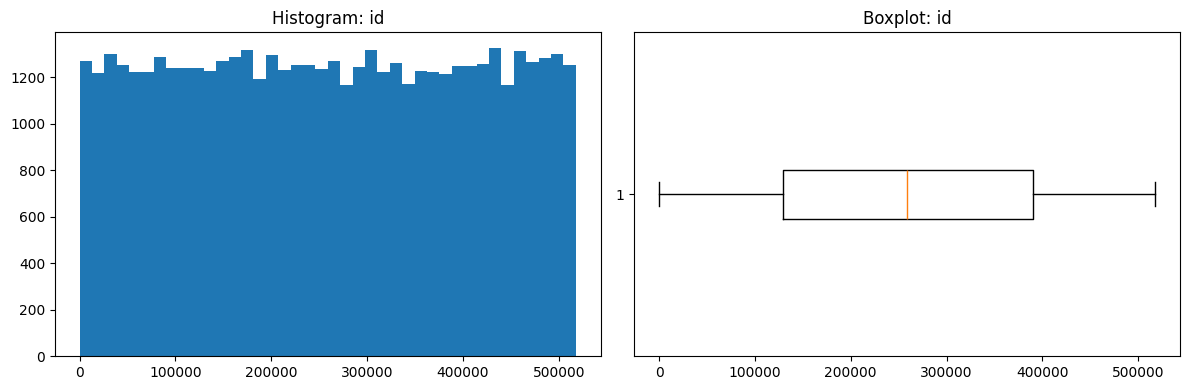

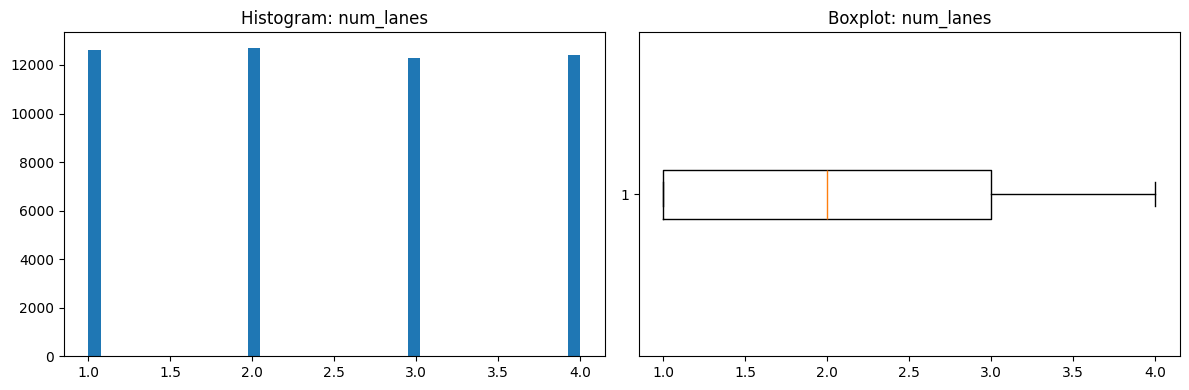

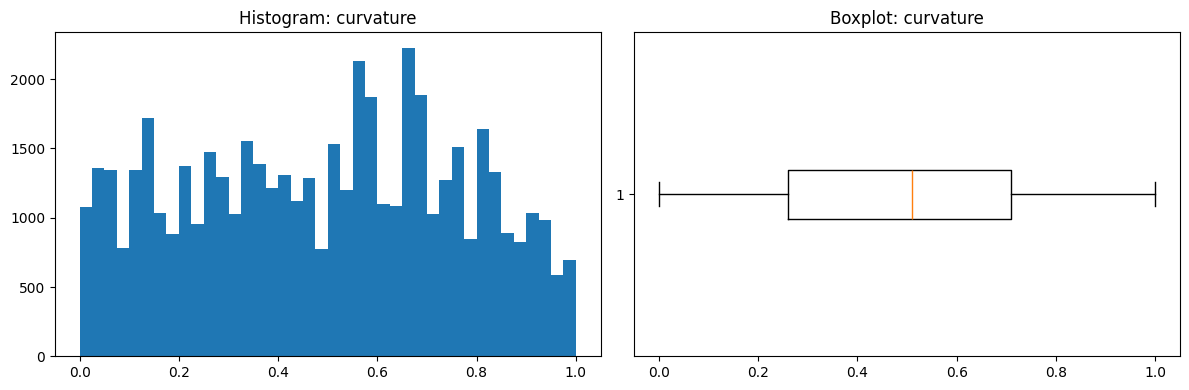

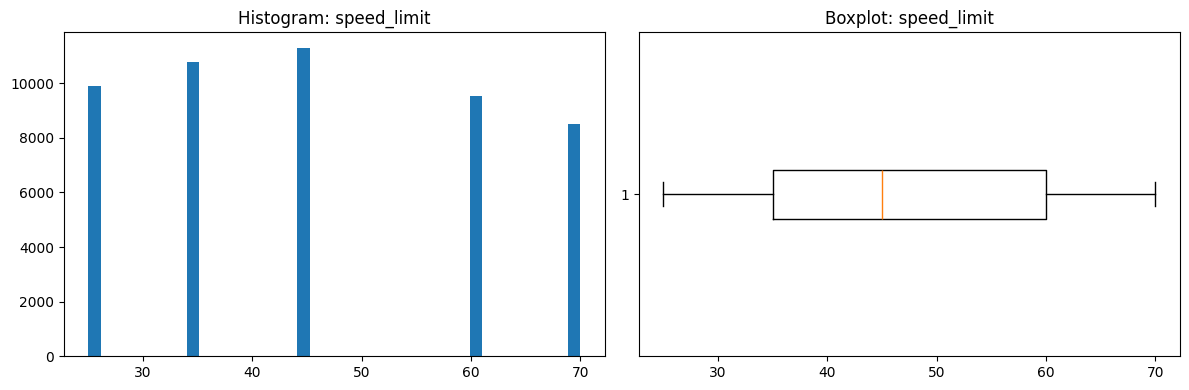

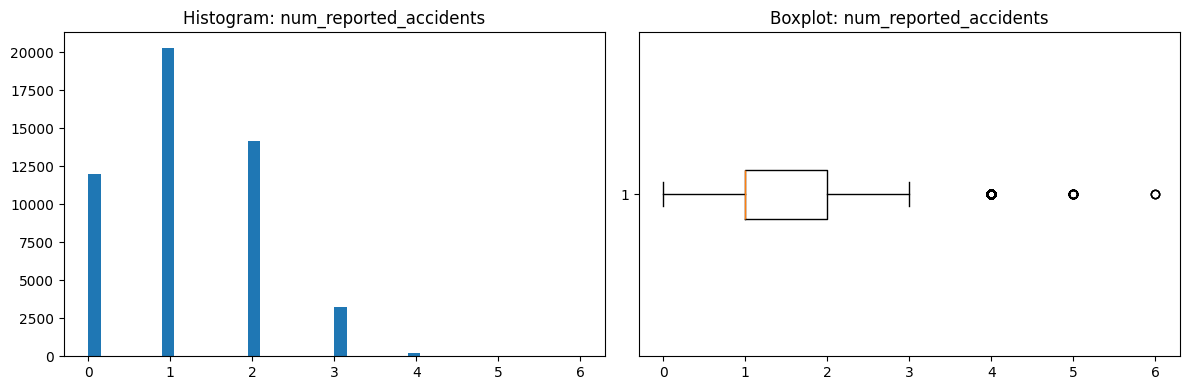

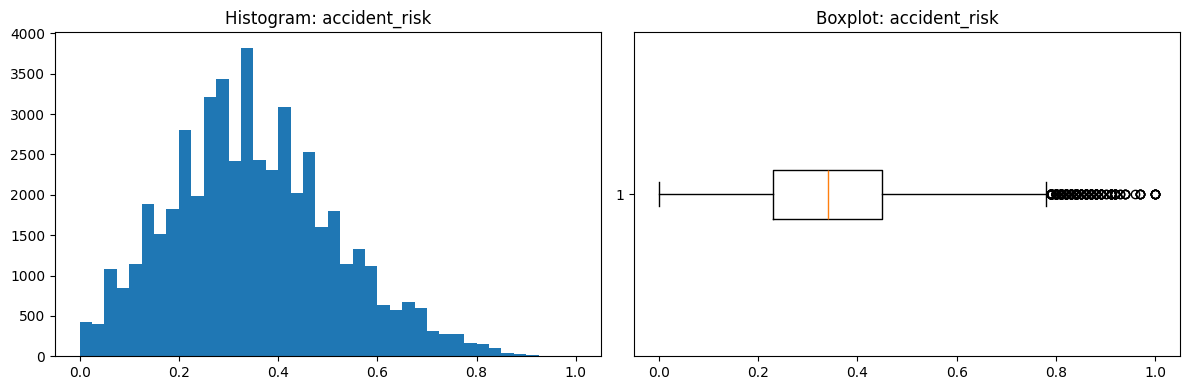

In [7]:
# For plots, sample data if large
SAMPLE_MAX = 50000
plot_df = df2.sample(n=min(SAMPLE_MAX, df2.shape[0]), random_state=42) if df2.shape[0] > SAMPLE_MAX else df2.copy()

# Histograms + boxplots for numeric columns (limit to first 6 to avoid heavy plotting)
for col in numeric_cols[:6]:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    axs[0].hist(plot_df[col].dropna(), bins=40)
    axs[0].set_title(f"Histogram: {col}")
    axs[1].boxplot(plot_df[col].dropna().astype(float), vert=False)
    axs[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()
    sk = df2[col].skew()
    if abs(sk) > 1:
        print(f" - Insight: {col} is skewed (skew={sk:.2f}) — consider log or transform.")


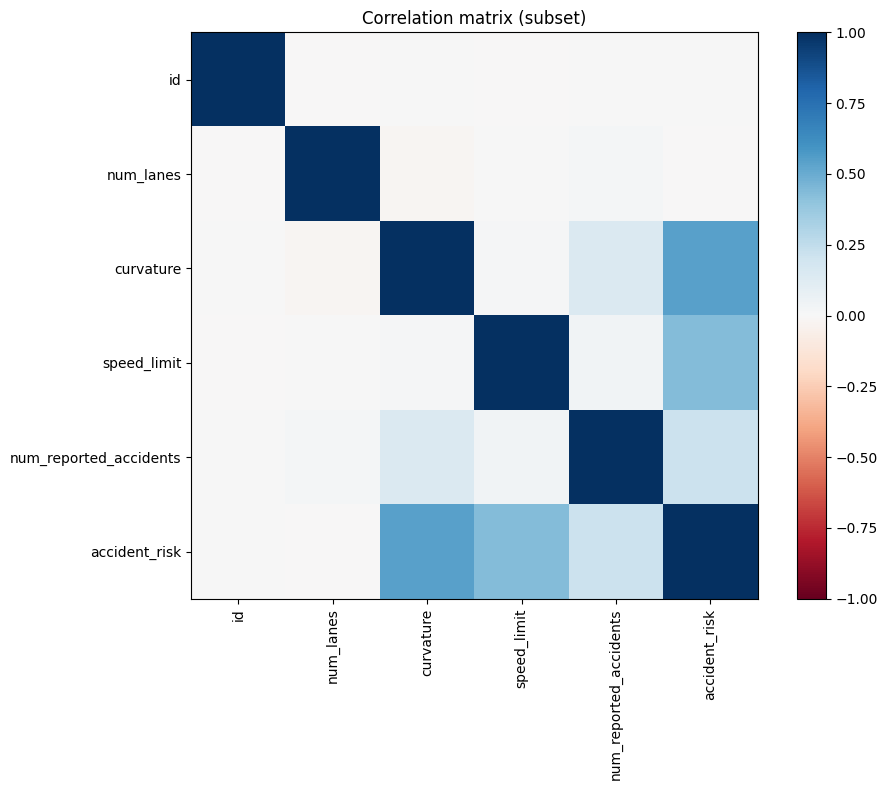

In [8]:
# Correlation heatmap for numeric features (subset if many)
if len(numeric_cols) >= 2:
    cols_for_corr = numeric_cols[:12]  # top 12 numeric columns
    corr = df2[cols_for_corr].corr()
    plt.figure(figsize=(10,8))
    plt.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(cols_for_corr)), cols_for_corr, rotation=90)
    plt.yticks(range(len(cols_for_corr)), cols_for_corr)
    plt.title("Correlation matrix (subset)")
    plt.tight_layout()
    plt.show()

    # find strong correlations
    strong_pairs = []
    for i in range(len(cols_for_corr)):
        for j in range(i+1, len(cols_for_corr)):
            if abs(corr.iloc[i,j]) > 0.8:
                strong_pairs.append((cols_for_corr[i], cols_for_corr[j], corr.iloc[i,j]))
    if strong_pairs:
        print("Strongly correlated pairs (|corr|>0.8):")
        for a,b,v in strong_pairs:
            print(f"  {a} <-> {b} : {v:.3f}")


In [9]:
# Detect outliers using IQR and report percent of outliers per numeric feature
outlier_summary = []
for c in numeric_cols:
    ser = df2[c].dropna().astype(float)
    if ser.shape[0] == 0: continue
    q1 = ser.quantile(0.25)
    q3 = ser.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out = ser[(ser < lower) | (ser > upper)]
    outlier_summary.append({'feature': c, 'n_outliers': int(out.shape[0]), 'pct_outliers': round(100*out.shape[0]/ser.shape[0],2)})
out_df = pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)
display(out_df)


,feature,n_outliers,pct_outliers
5,accident_risk,3367,0.65
4,num_reported_accidents,2649,0.51
1,num_lanes,0,0.00
0,id,0,0.00
3,speed_limit,0,0.00
2,curvature,0,0.00


# **EDA quick-insights (write or print these after you run the cells)**
### - Which numeric features are skewed and may benefit from log-transform.
### - Which pairs are highly correlated (possible multicollinearity).
### - Which features have many outliers (consider capping, winsorizing, or using robust models).


In [10]:
# Datetime feature extraction
for dt in datetime_cols:
    df2[f"{dt}_year"] = df2[dt].dt.year
    df2[f"{dt}_month"] = df2[dt].dt.month
    df2[f"{dt}_day"] = df2[dt].dt.day
    df2[f"{dt}_weekday"] = df2[dt].dt.weekday
    print(f"Extracted date parts for: {dt}")

# Recompute feature lists (exclude target if present)
all_numeric = df2.select_dtypes(include=[np.number]).columns.tolist()
all_datetime = df2.select_dtypes(include=['datetime','datetime64']).columns.tolist()
all_categorical = [c for c in df2.columns if c not in all_numeric + all_datetime]
display(pd.DataFrame({'numeric': len(all_numeric), 'categorical': len(all_categorical), 'datetime': len(all_datetime)}, index=[0]))

# Example suggested new features (uncomment and adapt if you have domain knowledge)
# - Ratios: e.g., accidents per lane: df2['accidents_per_lane'] = df2['num_accidents'] / (df2['num_lanes'] + 1e-6)
# - Aggregates: rolling means, counts by category (groupby transforms), etc.

,numeric,categorical,datetime
0,6,8,0


In [26]:
# Prepare preprocessing transformers for modeling
# We'll choose:
#  - numeric: median imputation + StandardScaler
#  - categorical: small-cardinality -> OneHot, high-cardinality -> Ordinal

# re-evaluate lists and exclude identifier columns like 'id' if present
id_like = [c for c in all_numeric if c.lower() in ('id','index','uid')][:5]
features_numeric = [c for c in all_numeric if c not in id_like]
target_col = 'accident_risk'  # adjust target column name if needed
features_numeric.remove(target_col) if target_col in features_numeric else None
features_categorical = [c for c in all_categorical if c not in id_like]

# For categorical split by cardinality
low_card = [c for c in features_categorical if df2[c].nunique(dropna=True) <= 20]
high_card = [c for c in features_categorical if df2[c].nunique(dropna=True) > 20]

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_low_transformer = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
cat_high_transformer = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, features_numeric),
    ('cat_low', cat_low_transformer, low_card),
    ('cat_high', cat_high_transformer, high_card),
], remainder='drop', sparse_threshold=0)

print("Preprocessor prepared.")

Preprocessor prepared.


# ## 5. Model Planning
### - Detect target column (tries common names or uses last column heuristics)
### - Decide classification vs regression based on dtype and cardinality
### - Choose baseline candidates:
###   - Classification: LogisticRegression, RandomForestClassifier
###   - Regression: LinearRegression, RandomForestRegressor
### - Evaluation strategy: train/test + cross-validation

In [28]:
# Heuristic to detect target column
possible_names = [c for c in df2.columns if c.lower() in ('target','label','y','outcome','class','dependent','accident_risk','is_target')]
if possible_names:
    target = possible_names[0]
else:
    # fallback: pick last column (careful)
    target = df2.columns[-1]

print("Picked target (heuristic):", target)
print("Target dtype:", df2[target].dtype, "Unique:", df2[target].nunique())

# Decide problem type
if df2[target].dtype.kind in 'biu' or (df2[target].dtype.kind == 'i' and df2[target].nunique() <= 20) or df2[target].dtype == bool:
    problem_type = 'classification' if df2[target].nunique() <= 20 else 'regression'
elif df2[target].dtype.kind in 'fc':
    problem_type = 'regression' if df2[target].nunique() > 20 else 'classification'
else:
    problem_type = 'classification' if df2[target].nunique() <= 20 else 'regression'
print("Planned problem type:", problem_type)


Picked target (heuristic): accident_risk
Target dtype: float64 Unique: 98
Planned problem type: regression


# ## 6. Model Implementation (Baseline)
### - Build a pipeline combining the preprocessor and a baseline model
### - Train/test split
### - Fit model and evaluate

In [29]:
# Prepare data for modeling - drop rows with missing target
model_df = df2.dropna(subset=[target]).reset_index(drop=True)
X = model_df.drop(columns=[target])
y = model_df[target]

# Optionally drop identifiers from X
for idc in id_like:
    if idc in X.columns:
        X = X.drop(columns=[idc])

# Train-test split
if problem_type == 'classification':
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (414203, 12) Test shape: (103551, 12)


In [30]:
X_train

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
143159,rural,2,0.43,60,dim,clear,False,False,afternoon,True,True,2
20172,highway,4,0.18,25,night,clear,False,False,afternoon,True,False,1
57926,urban,1,0.20,70,night,clear,False,True,morning,True,True,1
193319,urban,3,0.81,60,daylight,foggy,True,False,evening,True,True,1
213938,rural,3,0.43,35,night,rainy,False,True,morning,True,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...
259178,rural,4,0.05,60,dim,clear,False,True,morning,True,False,1
365838,rural,3,0.47,70,dim,rainy,False,False,evening,True,True,1
131932,highway,3,0.51,70,night,clear,True,True,afternoon,False,True,2
146867,rural,3,0.91,60,night,rainy,True,False,evening,False,False,4


In [31]:
# Baseline model training and evaluation
if problem_type == 'classification':
    model = Pipeline([('preproc', preprocessor),
                      ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 (weighted):", f1_score(y_test, y_pred, average='weighted'))
    print("\nClassification report:\n", classification_report(y_test, y_pred))
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Probability-based metrics (if available)
    try:
        y_proba = model.predict_proba(X_test)
        if y_proba.shape[1] == 2:
            auc = roc_auc_score(y_test, y_proba[:,1])
            print("ROC AUC (binary):", auc)
    except Exception:
        pass

elif problem_type == 'regression':
    model = Pipeline([('preproc', preprocessor),
                      ('reg', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)

# Save pipeline
MODEL_PATH = r"../data/road_accidents/final_model.pkl"
with open(MODEL_PATH, "wb") as f:
    pickle.dump(model, f)
print("Saved model to:", MODEL_PATH)


RMSE: 0.059414809290755155
MAE: 0.04610057039049137
R2: 0.8721536025265739
Saved model to: ../data/road_accidents/final_model.pkl


# ## 7. Model Interpretation & Optimization
### - Show feature importance (permutation importance to be robust)
### - Give recommendations for hyperparameter tuning and advanced models


In [ ]:
# Permutation importance (works for both classifier & regressor)
# We need the numeric matrix after preprocessor transform for the test set
# Not Working
try:
    transformer = model.named_steps['preproc']
    model_core = model.named_steps[list(model.named_steps.keys())[-1]]  # the last step (clf/reg)
    X_test_trans = transformer.transform(X_test)

    # Compute feature names in correct order
    feature_names = []
    # numeric
    feature_names.extend(features_numeric)
    # cat low (onehot)
    if low_card:
        ohe = transformer.named_transformers_['cat_low'].named_steps['onehot']
        ohe_names = ohe.get_feature_names_out(low_card).tolist()
        feature_names.extend(ohe_names)
    # cat high (ordinal)
    feature_names.extend(high_card)

    perm = permutation_importance(model_core, X_test_trans, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    imp_df = pd.DataFrame({'feature': feature_names, 'importance_mean': perm.importances_mean, 'importance_std': perm.importances_std})
    imp_df = imp_df.sort_values('importance_mean', ascending=False).reset_index(drop=True)
    display(imp_df.head(40))
except Exception as e:
    print("Permutation importance failed:", e)


Permutation importance failed: Could not pickle the task to send it to the workers.


# **Hyperparameter tuning suggestions**
### - RandomizedSearchCV over:
###   - `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`
### - For classification with imbalance: use `class_weight='balanced'` or SMOTE + pipeline
### - Try LightGBM/XGBoost for tabular speed & accuracy (if available)


# ## 8. Insights, Recommendations & Next Steps
### - Summarize findings (write this after you run notebook and examine outputs)
### - Consider collecting more features if necessary
### - For deployment: serialize pipeline (done above) and create an inference function that does `model.predict(X_new)`
### - Additional experiments: advanced feature interactions, target encoding for high-cardinality cats, stacking/ensembles

In [1]:
# Full experiment: RandomForest, GradientBoosting (sklearn), XGBoost (if installed)
# - Exclude target from features
# - OneHotEncoder: sparse_output compatibility handled
# - Efficient default hyperparams; supports optional sampling if memory is constrained
# - Saves models and results to /mnt/data/

import warnings, time, os
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np, math, pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optional: permutation importance
from sklearn.inspection import permutation_importance

# Try import xgboost
USE_XGBOOST = True
try:
    import xgboost as xgb
    from xgboost import XGBRegressor
    print("xgboost available:", xgb.__version__)
except Exception:
    USE_XGBOOST = False
    print("xgboost not available, will skip XGBoost.")

# ---- Settings ----
DATA_PATH = r"../data/road_accidents/train.csv"        # change if necessary
TARGET = "accident_risk"                 # your target column
SAMPLE_FOR_DEVELOP = None                # set to e.g. 200000 for faster dev; None -> use full file
MAX_ROWS_TO_READ = None                  # set to limit memory while reading (None -> read all)
SAMPLE_FOR_MODELS = None                 # if you want to train on a subset, set integer (e.g. 100000)
N_EST = 100                              # n_estimators for tree models (increase for production)
RANDOM_STATE = 42

# ---- Utility: build preprocessor (excludes target) ----
def build_preprocessor(X_df):
    numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_df.select_dtypes(include=['object','category','bool']).columns.tolist()
    low_card = [c for c in cat_cols if X_df[c].nunique(dropna=True) <= 20]
    high_card = [c for c in cat_cols if X_df[c].nunique(dropna=True) > 20]

    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    # OneHotEncoder: try sparse_output first (sklearn>=1.2), fallback to sparse
    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
    cat_low_pipe = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', ohe)])
    cat_high_pipe = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

    preproc = ColumnTransformer(transformers=[
        ('num', num_pipe, numeric_cols),
        ('cat_low', cat_low_pipe, low_card),
        ('cat_high', cat_high_pipe, high_card)
    ], remainder='drop', sparse_threshold=0)

    return preproc, numeric_cols, low_card, high_card

# ---- 1) Load data ----
print("Loading data from:", DATA_PATH)
df = pd.read_csv(DATA_PATH, nrows=MAX_ROWS_TO_READ) if MAX_ROWS_TO_READ is not None else pd.read_csv(DATA_PATH)
print("Full dataset shape:", df.shape)

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Columns: {df.columns.tolist()[:20]}")

# Optionally sample for fast development
if SAMPLE_FOR_DEVELOP:
    df = df.sample(min(SAMPLE_FOR_DEVELOP, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
    print("Sampled for dev -> shape:", df.shape)

# ---- 2) Prepare X/y ----
X_full = df.drop(columns=[TARGET]).copy()
y_full = df[TARGET].copy()

# drop id-like columns
id_cols = [c for c in X_full.columns if c.lower() in ('id','uid','index')]
if id_cols:
    print("Dropping id-like cols:", id_cols)
    X_full.drop(columns=id_cols, inplace=True)

if SAMPLE_FOR_MODELS and SAMPLE_FOR_MODELS < len(X_full):
    idx = np.random.choice(X_full.index, size=SAMPLE_FOR_MODELS, replace=False)
    X = X_full.loc[idx].reset_index(drop=True)
    y = y_full.loc[idx].reset_index(drop=True)
    print("Training on subset rows:", SAMPLE_FOR_MODELS)
else:
    X = X_full.copy()
    y = y_full.copy()

print("Features:", X.shape, "Target:", y.shape)

# ---- 3) Build preprocessor & split ----
preproc, num_cols, low_card, high_card = build_preprocessor(X)
print("Numeric features:", len(num_cols), "low-cardinality cats:", len(low_card), "high-cardinality cats:", len(high_card))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# ---- 4) Models to run ----
models_config = {
    'RandomForest': RandomForestRegressor(n_estimators=N_EST, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE),
    'GradBoost': GradientBoostingRegressor(n_estimators=N_EST, max_depth=6, random_state=RANDOM_STATE)
}
if USE_XGBOOST:
    models_config['XGBoost'] = XGBRegressor(n_estimators=N_EST, max_depth=6, n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE, verbosity=0)

# Directory to save
os.makedirs('../data/road_accidents/models', exist_ok=True)

results = []
trained_pipelines = {}

for name, core in models_config.items():
    print("\n--- Training", name, " ---")
    pipeline = Pipeline([('preprocessor', preproc), ('model', core)])
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    dt = time.time() - t0
    print(f"Trained {name} in {dt:.1f}s")
    # predict & metrics
    y_pred = pipeline.predict(X_test)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} metrics: RMSE={rmse:.5f}, MAE={mae:.5f}, R2={r2:.5f}")
    results.append({'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'train_time_s': dt})
    trained_pipelines[name] = pipeline

    # save pipeline
    path = fr"../data/road_accidents/models/{name}_pipeline.pkl"
    with open(path, "wb") as f:
        pickle.dump(pipeline, f)
    print("Saved pipeline to:", path)

# ---- 5) Feature importances (fast) ----
def get_feature_names(preproc, num_cols, low_card, high_card):
    feat_names = list(num_cols)
    if low_card:
        ohe = preproc.named_transformers_['cat_low'].named_steps['onehot']
        try:
            ohe_names = ohe.get_feature_names_out(low_card).tolist()
        except Exception:
            ohe_names = ohe.get_feature_names(low_card).tolist()
        feat_names.extend(ohe_names)
    feat_names.extend(high_card)
    return feat_names

feature_importances = {}
for name, pipe in trained_pipelines.items():
    core = pipe.named_steps['model']
    pre = pipe.named_steps['preprocessor']
    feats = get_feature_names(pre, num_cols, low_card, high_card)
    if hasattr(core, 'feature_importances_'):
        imp = core.feature_importances_
        # align lengths
        minlen = min(len(imp), len(feats))
        imp_df = pd.DataFrame({'feature': feats[:minlen], 'importance': imp[:minlen]}).sort_values('importance', ascending=False)
        imp_path = fr"../data/road_accidents/models/feature_importances_{name}.csv"
        imp_df.to_csv(imp_path, index=False)
        feature_importances[name] = imp_df
        print(f"Saved importances for {name} ({imp_df.shape[0]} features) -> {imp_path}")

# ---- 6) Permutation importance (optional - heavy). Use a sampled test subset ----
DO_PERMUTATION = False   # set True if you want this (be aware it's slow)
if DO_PERMUTATION:
    sample_n = min(3000, X_test.shape[0])
    idx = np.random.choice(X_test.index, size=sample_n, replace=False)
    X_test_samp = X_test.loc[idx]
    y_test_samp = y_test.loc[idx]
    X_test_trans = preproc.transform(X_test_samp)
    for name, pipe in trained_pipelines.items():
        print("Permutation importance for", name)
        core = pipe.named_steps['model']
        perm = permutation_importance(core, X_test_trans, y_test_samp, n_repeats=6, random_state=RANDOM_STATE, n_jobs=-1)
        perm_df = pd.DataFrame({'feature': get_feature_names(preproc, num_cols, low_card, high_card)[:len(perm.importances_mean)],
                                'importance_mean': perm.importances_mean, 'importance_std': perm.importances_std})
        perm_df = perm_df.sort_values('importance_mean', ascending=False)
        perm_df.to_csv(fr"../data/road_accidents/models/perm_importance_{name}.csv", index=False)

# ---- 7) Save comparison table & plotting ----
res_df = pd.DataFrame(results).sort_values('r2', ascending=False).reset_index(drop=True)
res_df.to_csv(r"../data/road_accidents/models/model_comparison.csv", index=False)
print("\nModel comparison saved to ../data/road_accidents/models/model_comparison.csv")
display(res_df)

# Simple comparison plot
plt.figure(figsize=(8,4))
sns.barplot(x='model', y='r2', data=res_df)
plt.title("Model R^2 comparison")
plt.show()

# Residual plot for best model
best_name = res_df.loc[0,'model']
best_pipe = trained_pipelines[best_name]
y_pred_best = best_pipe.predict(X_test)
resid = y_test - y_pred_best
plt.figure(figsize=(6,4))
plt.scatter(y_pred_best[:2000], resid[:2000], s=6)
plt.axhline(0, linestyle='--'); plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.title(f'Residuals: {best_name}')
plt.show()

print("Done. Models & results are under ../data/road_accidents/models/")


xgboost available: 3.1.1
Loading data from: ../data/road_accidents/train.csv
Full dataset shape: (517754, 14)
Dropping id-like cols: ['id']
Features: (517754, 12) Target: (517754,)
Numeric features: 4 low-cardinality cats: 8 high-cardinality cats: 0


          model      rmse       mae        r2  train_time_s
0       XGBoost  0.056270  0.043675  0.885331      8.996407
1     GradBoost  0.056283  0.043686  0.885276    126.319914
2  RandomForest  0.059415  0.046101  0.872154     27.440818


<Axes: xlabel='model'>

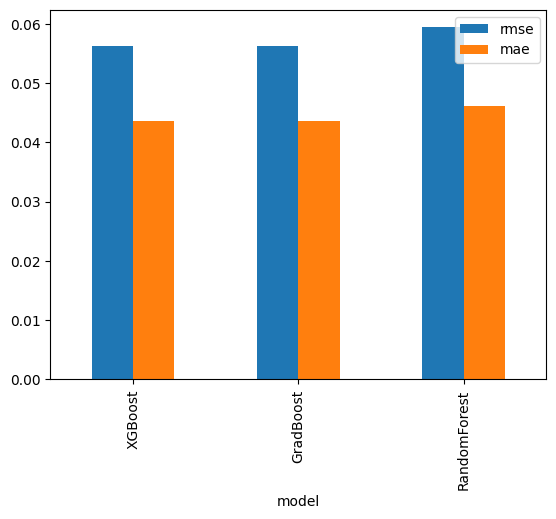

In [34]:
print(pd.read_csv("../data/road_accidents/models/model_comparison.csv"))
res = pd.read_csv("../data/road_accidents/models/model_comparison.csv")
res.plot.bar(x='model', y=['rmse','mae'])


In [37]:
for i in res['model'].to_list():
    fi = pd.read_csv(f"../data/road_accidents/models/feature_importances_{i}.csv")
    print(f"Feature importances for model: {i}")
    print(fi.head(20))



Feature importances for model: XGBoost
                     feature  importance
0             lighting_night    0.519318
1                speed_limit    0.204201
2              weather_clear    0.130552
3                  curvature    0.110366
4     num_reported_accidents    0.026849
5              weather_foggy    0.001716
6              weather_rainy    0.001049
7              holiday_False    0.000850
8          lighting_daylight    0.000734
9          public_road_False    0.000723
10       time_of_day_morning    0.000463
11       time_of_day_evening    0.000416
12              lighting_dim    0.000383
13  road_signs_present_False    0.000382
14       school_season_False    0.000369
15                 num_lanes    0.000354
16         road_type_highway    0.000342
17           road_type_urban    0.000319
18     time_of_day_afternoon    0.000311
19           road_type_rural    0.000304
Feature importances for model: GradBoost
                     feature  importance
0                 

In [2]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# === Define base models ===
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
# rf_model = RandomForestRegressor(random_state=42)

# === Define parameter grids ===
xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

# rf_param_grid = {
#     'model__n_estimators': [100, 200],
#     'model__max_depth': [None, 10, 20],
#     'model__min_samples_split': [2, 5],
#     'model__min_samples_leaf': [1, 2]
# }

# === Create Pipelines ===
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline([
    ('preprocessor', preproc),
    ('model', xgb_model)
])

# rf_pipeline = Pipeline([
#     ('preprocessor', preproc),
#     ('model', rf_model)
# ])

# === GridSearchCV for both ===
xgb_search = GridSearchCV(
    xgb_pipeline, xgb_param_grid,
    cv=3, scoring='r2', n_jobs=-1, verbose=2
)

# rf_search = GridSearchCV(
#     rf_pipeline, rf_param_grid,
#     cv=3, scoring='r2', n_jobs=-1, verbose=2
# )

# === Fit ===
xgb_search.fit(X_train, y_train)
# rf_search.fit(X_train, y_train)

# === Evaluate ===
xgb_best = xgb_search.best_estimator_
# rf_best = rf_search.best_estimator_

xgb_preds = xgb_best.predict(X_test)
# rf_preds = rf_best.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_preds)
# rf_r2 = r2_score(y_test, rf_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
# rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("=== Model Comparison ===")
print(f"XGBoost  | Best Params: {xgb_search.best_params_}")
print(f"          | R² = {xgb_r2:.4f}, RMSE = {xgb_rmse:.4f}")
# print(f"RandomForest | Best Params: {rf_search.best_params_}")
# print(f"             | R² = {rf_r2:.4f}, RMSE = {rf_rmse:.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
=== Model Comparison ===
XGBoost  | Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.8}
          | R² = 0.8858, RMSE = 0.0562
